# 05. Forecast evaluation: B0, B1, B2, B3 common-eps

This notebook combines the forecast-estimation workflow and the paper-level forecast tables/figures. It uses `./data/SP_monthly_sector_and_all.csv` when available and otherwise falls back to `./data/SAMPLE.csv` for workflow demonstration.

In [1]:
# ============================================================
# 0. Setup
# ============================================================

from pathlib import Path
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binom, betabinom, norm
from scipy.optimize import brentq, minimize

import pymc as pm
import arviz as az
import pytensor.tensor as pt

warnings.filterwarnings("ignore")

SEED = 12345
rng_global = np.random.default_rng(SEED)

DATA_DIR = Path("./data")
PDATA_DIR = Path("./pdata")
FIG_DIR = Path("./figures")
TABLE_DIR = Path("./tables")
PAPER_FIG_DIR = Path("./figures_paper_common_eps")
PAPER_TABLE_DIR = Path("./tables_paper_common_eps")
FIT_DIR = PDATA_DIR / "bayes_rolling_fits_k12_B2_B3_common_eps"

for d in [DATA_DIR, PDATA_DIR, FIG_DIR, TABLE_DIR, PAPER_FIG_DIR, PAPER_TABLE_DIR, FIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Data-loading policy for the public repository:
#   1. Use the proprietary empirical data if ./data/SP_monthly_sector_and_all.csv exists.
#   2. Otherwise use ./data/SAMPLE.csv for workflow demonstration.
# The synthetic SAMPLE.csv is not intended to reproduce the paper's empirical numbers.
REAL_INPUT_PATH = DATA_DIR / "SP_monthly_sector_and_all.csv"
SAMPLE_INPUT_PATH = DATA_DIR / "SAMPLE.csv"

MODEL_TAG = "05_forecast_B0_B1_B2_B3_ar1_binomial_common_eps"

K_FORECAST = 12
FACTOR_TRAIN_WINDOWS = [120, 240]
B0_CANDIDATE_WINDOWS = [12, 24, 36, 60, 120, 180, 240]
B0_MODEL_NAME = "B0_sector_constant_rate_binomial"
B1_MODEL_NAME = "B1_sector_constant_rate_betabinomial"

B0_BEST_LOG_MODEL = "B0_Binomial_best_expost_logscore"
B0_BEST_CRPS_MODEL = "B0_Binomial_best_expost_crps"
B0_BEST_COV90_MODEL = "B0_Binomial_best_expost_coverage90"

B1_BEST_LOG_MODEL = "B1_BetaBinomial_best_expost_logscore"
B1_BEST_CRPS_MODEL = "B1_BetaBinomial_best_expost_crps"
B1_BEST_COV90_MODEL = "B1_BetaBinomial_best_expost_coverage90"

B2_MODEL = "B2_bayes_fixed_eigen_AR1_binomial_common_eps"
B3_MODEL = "B3_bayes_fixed_eigen_AR1_binomial_common_eps"

# Intraclass-correlation parameter bounds for the Beta-Binomial baseline.
B1_BB_RHO_MIN = 1e-10
B1_BB_RHO_MAX = 0.05
BAYES_FACTORS = [1, 2]  # R=1 -> B2, R=2 -> B3

# ------------------------------------------------------------
# Default MCMC settings for the empirical-data run.
# These are intentionally kept in one cell so that users can edit them.
# ------------------------------------------------------------
DRAWS = 1000
TUNE = 1000
CHAINS = 4
CORES = 4
TARGET_ACCEPT = 0.99
N_FORECAST_SAMPLES = 2000
MAX_ORIGINS_PER_SETTING = None

# Reuse saved idata for each rolling fit when available.
REUSE_IDATA = True
RUN_BAYES = True

USE_COMMON_EPS_IN_FIT = True
USE_COMMON_EPS_IN_FORECAST = True
EXCLUDE_ALL_IF_OTHER_SECTORS_EXIST = True
PMF_EPS = 1e-12
LOG_FLOOR = 1e-300

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "figure.dpi": 120,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

print("MODEL_TAG:", MODEL_TAG)
print("K_FORECAST:", K_FORECAST)
print("B0_CANDIDATE_WINDOWS:", B0_CANDIDATE_WINDOWS)
print("B0_MODEL_NAME:", B0_MODEL_NAME)
print("B1_MODEL_NAME:", B1_MODEL_NAME)
print("FACTOR_TRAIN_WINDOWS:", FACTOR_TRAIN_WINDOWS)
print("BAYES_FACTORS:", BAYES_FACTORS)
print("Default DRAWS/TUNE/CHAINS:", DRAWS, TUNE, CHAINS)
print("Notebook version: 05 forecast evaluation common-eps public workflow")


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


MODEL_TAG: 05_forecast_B0_B1_B2_B3_ar1_binomial_common_eps
K_FORECAST: 12
B0_CANDIDATE_WINDOWS: [12, 24, 36, 60, 120, 180, 240]
B0_MODEL_NAME: B0_sector_constant_rate_binomial
B1_MODEL_NAME: B1_sector_constant_rate_betabinomial
FACTOR_TRAIN_WINDOWS: [120, 240]
BAYES_FACTORS: [1, 2]
Default DRAWS/TUNE/CHAINS: 1000 1000 4
Notebook version: 05 forecast evaluation common-eps public workflow


## 1. Load monthly sector data

In [2]:
# ============================================================
# 1. Load monthly sector default data
# ============================================================

def find_input_path():
    if REAL_INPUT_PATH.exists():
        return REAL_INPUT_PATH, "real"
    if SAMPLE_INPUT_PATH.exists():
        return SAMPLE_INPUT_PATH, "sample"
    raise FileNotFoundError(
        "No input data found. Put either\n"
        f"  {REAL_INPUT_PATH}\n"
        "or\n"
        f"  {SAMPLE_INPUT_PATH}\n"
        "in the project directory."
    )


def check_required_columns(df, required, df_name="dataframe"):
    missing = set(required) - set(df.columns)
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {sorted(missing)}")

input_path_used, DATA_SOURCE = find_input_path()
print("Input file:", input_path_used)
print("DATA_SOURCE:", DATA_SOURCE)

# Lightweight settings for public SAMPLE.csv workflow demonstration.
# With the proprietary empirical data, the default paper settings above are retained.
if DATA_SOURCE == "sample":
    DRAWS = 200
    TUNE = 200
    CHAINS = 2
    CORES = 1
    TARGET_ACCEPT = 0.90
    N_FORECAST_SAMPLES = 500
    MAX_ORIGINS_PER_SETTING = 2
    print("Using lightweight SAMPLE settings:")
    print("  DRAWS/TUNE/CHAINS/CORES =", DRAWS, TUNE, CHAINS, CORES)
    print("  N_FORECAST_SAMPLES =", N_FORECAST_SAMPLES)
    print("  MAX_ORIGINS_PER_SETTING =", MAX_ORIGINS_PER_SETTING)
else:
    print("Using empirical-data settings:")
    print("  DRAWS/TUNE/CHAINS/CORES =", DRAWS, TUNE, CHAINS, CORES)
    print("  N_FORECAST_SAMPLES =", N_FORECAST_SAMPLES)
    print("  MAX_ORIGINS_PER_SETTING =", MAX_ORIGINS_PER_SETTING)

df_ms = pd.read_csv(input_path_used)

if "sector" not in df_ms.columns:
    df_ms["sector"] = "ALL"

check_required_columns(df_ms, ["date", "sector", "bonds", "defaulted"], df_name="df_ms")

df_ms = df_ms.copy()
df_ms["date"] = pd.to_datetime(df_ms["date"])
df_ms = df_ms.sort_values(["sector", "date"]).reset_index(drop=True)
df_ms["bonds"] = df_ms["bonds"].astype(int)
df_ms["defaulted"] = df_ms["defaulted"].astype(int)
df_ms["default_rate"] = df_ms["defaulted"] / df_ms["bonds"]

all_sectors = sorted(df_ms["sector"].unique())
if EXCLUDE_ALL_IF_OTHER_SECTORS_EXIST and ("ALL" in all_sectors) and (len(all_sectors) > 1):
    MODEL_SECTORS = [s for s in all_sectors if s != "ALL"]
else:
    MODEL_SECTORS = all_sectors

panel_L = (
    df_ms[df_ms["sector"].isin(MODEL_SECTORS)]
    .pivot(index="date", columns="sector", values="defaulted")
    .sort_index()
)
panel_N = (
    df_ms[df_ms["sector"].isin(MODEL_SECTORS)]
    .pivot(index="date", columns="sector", values="bonds")
    .sort_index()
)

# Keep only months with complete sector observations.
common_index = panel_L.dropna().index.intersection(panel_N.dropna().index)
panel_L = panel_L.loc[common_index].astype(int)
panel_N = panel_N.loc[common_index].astype(int)

SECTORS = list(panel_L.columns)
T, D = panel_L.shape
L_obs = panel_L.to_numpy(dtype=int)
N_obs = panel_N.to_numpy(dtype=int)

print("Sectors used in dynamic model:", SECTORS)
print("T, D:", T, D)
print("Date range:", panel_L.index.min(), "to", panel_L.index.max())

df_ms.to_csv(PDATA_DIR / "forecast_input_monthly_sector_data_used.csv", index=False)
panel_L.to_csv(PDATA_DIR / "forecast_panel_defaulted_by_sector.csv")
panel_N.to_csv(PDATA_DIR / "forecast_panel_bonds_by_sector.csv")


Input file: data\SP_monthly_sector_and_all.csv
DATA_SOURCE: real
Using empirical-data settings:
  DRAWS/TUNE/CHAINS/CORES = 1000 1000 4 4
  N_FORECAST_SAMPLES = 2000
  MAX_ORIGINS_PER_SETTING = None
Sectors used in dynamic model: ['Consumer', 'Energy', 'FI', 'Forest', 'Health', 'High Tech', 'Insurance', 'Leisure', 'Metal', 'Real Estate', 'Telecom', 'Transport', 'Utility']
T, D: 489 13
Date range: 1981-01-31 00:00:00 to 2021-09-30 00:00:00


In [3]:
# ============================================================
# 2. Rolling design utilities
# ============================================================

def make_forecast_origins(T, eval_start, k=K_FORECAST, step=K_FORECAST):
    origins = []
    t0 = int(eval_start)
    while t0 + k <= T:
        origins.append(t0)
        t0 += step
    if MAX_ORIGINS_PER_SETTING is not None:
        origins = origins[: int(MAX_ORIGINS_PER_SETTING)]
    return origins


def get_train_forecast_slices(t0, train_window, k=K_FORECAST):
    if t0 - train_window < 0:
        raise ValueError(f"Not enough history: t0={t0}, train_window={train_window}")
    train_sl = slice(t0 - train_window, t0)
    forecast_sl = slice(t0, t0 + k)
    return train_sl, forecast_sl


def feasible_b0_windows(eval_start):
    return [w for w in B0_CANDIDATE_WINDOWS if w <= eval_start]

rows = []
for W_eval in FACTOR_TRAIN_WINDOWS:
    origins = make_forecast_origins(T=T, eval_start=W_eval)
    for R in BAYES_FACTORS:
        rows.append({
            "evaluation_start_months": W_eval,
            "model_family": f"B{R} Bayesian factor",
            "train_window_months": W_eval,
            "k_month": K_FORECAST,
            "n_forecasts": len(origins),
            "first_origin": panel_L.index[origins[0]] if origins else pd.NaT,
            "last_origin": panel_L.index[origins[-1]] if origins else pd.NaT,
        })
    for W_b0 in feasible_b0_windows(W_eval):
        rows.append({
            "evaluation_start_months": W_eval,
            "model_family": "B0/B1 static candidate",
            "train_window_months": W_b0,
            "k_month": K_FORECAST,
            "n_forecasts": len(origins),
            "first_origin": panel_L.index[origins[0]] if origins else pd.NaT,
            "last_origin": panel_L.index[origins[-1]] if origins else pd.NaT,
        })

df_design = pd.DataFrame(rows)
design_path = TABLE_DIR / f"forecast_design_{MODEL_TAG}.csv"
df_design.to_csv(design_path, index=False)
print("saved:", design_path)
display(df_design)


saved: tables\forecast_design_05_forecast_B0_B1_B2_B3_ar1_binomial_common_eps.csv


,evaluation_start_months,model_family,train_window_months,k_month,n_forecasts,first_origin,last_origin
0,120,B1 Bayesian factor,120,12,30,1991-01-31,2020-01-31
1,120,B2 Bayesian factor,120,12,30,1991-01-31,2020-01-31
2,120,B0/B1 static candidate,12,12,30,1991-01-31,2020-01-31
3,120,B0/B1 static candidate,24,12,30,1991-01-31,2020-01-31
4,120,B0/B1 static candidate,36,12,30,1991-01-31,2020-01-31
5,120,B0/B1 static candidate,60,12,30,1991-01-31,2020-01-31
6,120,B0/B1 static candidate,120,12,30,1991-01-31,2020-01-31
7,240,B1 Bayesian factor,240,12,20,2001-01-31,2020-01-31
8,240,B2 Bayesian factor,240,12,20,2001-01-31,2020-01-31
9,240,B0/B1 static candidate,12,12,20,2001-01-31,2020-01-31


In [4]:
# ============================================================
# 3. Exact B0/B1 static predictive distributions and scoring utilities
# ============================================================

print("Notebook version check: static B0/B1 utilities include all compatibility aliases.", flush=True)

def estimate_B0_q(L_train, N_train):
    """Exposure-weighted empirical default rate. Kept for diagnostics/initialization."""
    defaults = L_train.sum(axis=0).astype(float)
    exposures = N_train.sum(axis=0).astype(float)
    q = defaults / np.maximum(exposures, 1.0)
    q = np.clip(q, 1e-12, 1.0 - 1e-12)
    return q


def _mean_rho_to_alpha_beta(mean, rho):
    """Convert mean/rho parameterization to scipy beta-binomial alpha/beta."""
    mean = float(np.clip(mean, 1e-12, 1.0 - 1e-12))
    rho = float(np.clip(rho, B1_BB_RHO_MIN, B1_BB_RHO_MAX))
    concentration = (1.0 - rho) / rho
    alpha = mean * concentration
    beta = (1.0 - mean) * concentration
    return float(alpha), float(beta)


def _initial_rho_moment(L_s, N_s, mean):
    """Method-of-moments starting value for beta-binomial intraclass correlation."""
    L_s = np.asarray(L_s, dtype=float)
    N_s = np.asarray(N_s, dtype=float)
    ok = N_s > 0
    L_s = L_s[ok]
    N_s = N_s[ok]

    if len(L_s) < 3:
        return 1e-5

    rates = L_s / N_s
    v_obs = float(np.var(rates, ddof=1))
    binom_part = float(np.mean(mean * (1.0 - mean) / np.maximum(N_s, 1.0)))
    rho_scale = float(np.mean(mean * (1.0 - mean) * (N_s - 1.0) / np.maximum(N_s, 1.0)))

    if not np.isfinite(v_obs) or not np.isfinite(rho_scale) or rho_scale <= 0:
        return 1e-5

    rho0 = (v_obs - binom_part) / rho_scale
    return float(np.clip(rho0, B1_BB_RHO_MIN * 10.0, B1_BB_RHO_MAX * 0.5))


def estimate_B0_betabinom_params(L_train, N_train):
    """
    Estimate sector-specific Beta-Binomial parameters from the rolling training window.

    Model:
        L_{tau,s} ~ BetaBinomial(N_{tau,s}, alpha_s, beta_s)

    The returned forecast parameters are (alpha_s, beta_s), with the mean and rho
    also returned for diagnostics.  This is the direct counterpart of the previous
    constant-rate Binomial B0, but with an additional overdispersion parameter.
    """
    L_train = np.asarray(L_train, dtype=float)
    N_train = np.asarray(N_train, dtype=float)

    n_sector = L_train.shape[1]
    alpha = np.empty(n_sector, dtype=float)
    beta = np.empty(n_sector, dtype=float)
    mean = np.empty(n_sector, dtype=float)
    rho = np.empty(n_sector, dtype=float)
    converged = np.zeros(n_sector, dtype=bool)

    for s in range(n_sector):
        L_s = L_train[:, s]
        N_s = N_train[:, s]
        ok = N_s > 0
        L_s = L_s[ok]
        N_s = N_s[ok]

        # Exposure-weighted empirical mean.  This keeps the baseline close to
        # recent realized default rates, especially for short rolling windows.
        m0 = float(np.sum(L_s) / max(np.sum(N_s), 1.0))
        m0 = float(np.clip(m0, 1e-10, 1.0 - 1e-10))
        rho0 = _initial_rho_moment(L_s, N_s, m0)

        def unpack(theta):
            # theta[0] is logit(mean).
            m = 1.0 / (1.0 + np.exp(-theta[0]))
            # theta[1] is logit(rho / B1_BB_RHO_MAX).
            u = 1.0 / (1.0 + np.exp(-theta[1]))
            r = B1_BB_RHO_MIN + (B1_BB_RHO_MAX - B1_BB_RHO_MIN) * u
            a, b = _mean_rho_to_alpha_beta(m, r)
            return m, r, a, b

        def nll(theta):
            m, r, a, b = unpack(theta)
            ll = betabinom.logpmf(L_s.astype(int), N_s.astype(int), a, b)
            if not np.all(np.isfinite(ll)):
                return 1e100
            return float(-np.sum(ll))

        theta0 = np.array([
            np.log(m0 / (1.0 - m0)),
            np.log((rho0 - B1_BB_RHO_MIN) / max(B1_BB_RHO_MAX - rho0, 1e-30)),
        ])

        # Bounds keep the optimizer away from numerically extreme regions.
        bounds = [
            (np.log(1e-10 / (1.0 - 1e-10)), np.log((1.0 - 1e-10) / 1e-10)),
            (-30.0, 30.0),
        ]

        try:
            opt = minimize(nll, theta0, method="L-BFGS-B", bounds=bounds)
            if opt.success and np.isfinite(opt.fun):
                m_hat, r_hat, a_hat, b_hat = unpack(opt.x)
                converged[s] = True
            else:
                raise RuntimeError(str(opt.message))
        except Exception:
            # Conservative fallback: empirical mean + moment rho.
            m_hat, r_hat = m0, rho0
            a_hat, b_hat = _mean_rho_to_alpha_beta(m_hat, r_hat)

        alpha[s] = a_hat
        beta[s] = b_hat
        mean[s] = m_hat
        rho[s] = r_hat

    return {
        "alpha": alpha,
        "beta": beta,
        "mean": mean,
        "rho": rho,
        "converged": converged,
    }


def truncated_binom_pmf(n, p, y_include=None, eps=PMF_EPS):
    n = int(n)
    p = float(np.clip(p, 1e-15, 1.0 - 1e-15))
    lo = int(binom.ppf(eps, n, p))
    hi = int(binom.ppf(1.0 - eps, n, p))
    if y_include is not None:
        y_include = int(y_include)
        lo = min(lo, y_include)
        hi = max(hi, y_include)
    lo = max(0, lo)
    hi = min(n, hi)
    support = np.arange(lo, hi + 1, dtype=int)
    pmf = binom.pmf(support, n, p)
    total = pmf.sum()
    if not np.isfinite(total) or total <= 0:
        if y_include is None:
            y_include = int(round(n * p))
        support = np.asarray([int(y_include)], dtype=int)
        pmf = np.asarray([1.0], dtype=float)
    else:
        pmf = pmf / total
    return support, pmf


def truncated_betabinom_pmf(n, alpha, beta, y_include=None, eps=PMF_EPS):
    n = int(n)
    alpha = float(max(alpha, 1e-12))
    beta = float(max(beta, 1e-12))

    lo = int(betabinom.ppf(eps, n, alpha, beta))
    hi = int(betabinom.ppf(1.0 - eps, n, alpha, beta))

    if not np.isfinite(lo):
        lo = 0
    if not np.isfinite(hi):
        hi = n

    if y_include is not None:
        y_include = int(y_include)
        lo = min(lo, y_include)
        hi = max(hi, y_include)

    lo = max(0, int(lo))
    hi = min(n, int(hi))

    support = np.arange(lo, hi + 1, dtype=int)
    pmf = betabinom.pmf(support, n, alpha, beta)

    total = pmf.sum()
    if not np.isfinite(total) or total <= 0:
        # Fallback to the rounded mean if scipy underflows in an extreme corner.
        mean = n * alpha / (alpha + beta)
        if y_include is None:
            y_include = int(round(mean))
        support = np.asarray([int(y_include)], dtype=int)
        pmf = np.asarray([1.0], dtype=float)
    else:
        pmf = pmf / total

    return support, pmf


def convolve_discrete_distributions(dist_list):
    support_total = np.asarray([0], dtype=int)
    pmf_total = np.asarray([1.0], dtype=float)
    for support, pmf in dist_list:
        new_pmf = np.convolve(pmf_total, pmf)
        new_start = int(support_total[0] + support[0])
        new_support = np.arange(new_start, new_start + len(new_pmf), dtype=int)
        support_total, pmf_total = new_support, new_pmf
    total = pmf_total.sum()
    if total > 0:
        pmf_total = pmf_total / total
    return support_total, pmf_total


def convolve_independent_pmfs(sector_supports, sector_pmfs):
    """Backward-compatible helper for exact B0 sector-wise independent PMFs."""
    return convolve_discrete_distributions(list(zip(sector_supports, sector_pmfs)))


def log_pmf_at_y(support, pmf, y, log_floor=LOG_FLOOR):
    y = int(y)
    idx = np.where(support == y)[0]
    if len(idx) == 0:
        return float(np.log(log_floor))
    prob = float(pmf[idx[0]])
    return float(np.log(max(prob, log_floor)))



def log_score_from_pmf(support, pmf, y, log_floor=LOG_FLOOR):
    """Backward-compatible alias for exact PMF log scoring."""
    return log_pmf_at_y(support, pmf, y, log_floor=log_floor)

def crps_discrete(support, pmf, y):
    y = int(y)
    cdf = np.cumsum(pmf)
    indicator = (support >= y).astype(float)
    return float(np.sum((cdf - indicator) ** 2))


def predictive_interval(support, pmf, level=0.90):
    alpha = 1.0 - level
    cdf = np.cumsum(pmf)
    lo = support[np.searchsorted(cdf, alpha / 2.0, side="left")]
    hi = support[np.searchsorted(cdf, 1.0 - alpha / 2.0, side="left")]
    return int(lo), int(hi)



def predictive_interval_from_pmf(support, pmf, level=0.90):
    """Backward-compatible alias for predictive intervals from an exact PMF."""
    return predictive_interval(support, pmf, level=level)

def pmf_mean_var(support, pmf):
    mean = float(np.sum(support * pmf))
    var = float(np.sum((support - mean) ** 2 * pmf))
    return mean, var


def empirical_distribution_from_samples(samples, y_include=None, alpha=1e-6):
    samples = np.asarray(samples, dtype=int)
    max_count = int(samples.max()) if samples.size else 0
    if y_include is not None:
        max_count = max(max_count, int(y_include))
    max_count = max(max_count, 0)
    counts = np.bincount(samples, minlength=max_count + 1).astype(float)
    counts += float(alpha)
    pmf = counts / counts.sum()
    support = np.arange(max_count + 1, dtype=int)
    return support, pmf



def score_one_B0_forecast(t0, eval_start, train_window, k=K_FORECAST):
    """Exact sector-wise constant-rate Binomial baseline forecast."""
    train_sl, forecast_sl = get_train_forecast_slices(t0, train_window, k)
    L_train = L_obs[train_sl, :]
    N_train = N_obs[train_sl, :]
    L_forecast = L_obs[forecast_sl, :]
    N_forecast = N_obs[forecast_sl, :]
    q = estimate_B0_q(L_train=L_train, N_train=N_train)
    sector_supports, sector_pmfs, sector_log_scores, sector_crps = [], [], [], []
    observed_sector = L_forecast.sum(axis=0).astype(int)
    N_block = N_forecast[0, :].astype(int)
    for s_idx in range(D):
        y_s = int(observed_sector[s_idx])
        n_s = int(N_block[s_idx])
        support_s, pmf_s = truncated_binom_pmf(n=n_s, p=float(q[s_idx]), y_include=y_s, eps=PMF_EPS)
        sector_supports.append(support_s)
        sector_pmfs.append(pmf_s)
        sector_log_scores.append(log_score_from_pmf(support_s, pmf_s, y_s))
        sector_crps.append(crps_discrete(support_s, pmf_s, y_s))
    total_support, total_pmf = convolve_independent_pmfs(sector_supports, sector_pmfs)
    observed_portfolio = int(observed_sector.sum())
    log_score_portfolio = log_score_from_pmf(total_support, total_pmf, observed_portfolio)
    crps_portfolio = crps_discrete(total_support, total_pmf, observed_portfolio)
    intervals = {}
    for level in [0.50, 0.80, 0.90, 0.95]:
        lo, hi = predictive_interval_from_pmf(total_support, total_pmf, level)
        intervals[f"pi{int(level*100)}_lo"] = lo
        intervals[f"pi{int(level*100)}_hi"] = hi
        intervals[f"coverage_pi{int(level*100)}_portfolio"] = float(lo <= observed_portfolio <= hi)
    mean_p = float(np.sum(total_support * total_pmf))
    var_p = float(np.sum((total_support - mean_p)**2 * total_pmf))
    sector_means = [np.sum(sup * pmf) for sup, pmf in zip(sector_supports, sector_pmfs)]
    sector_sds = [np.sqrt(max(np.sum((sup - np.sum(sup * pmf))**2 * pmf), 0.0)) for sup, pmf in zip(sector_supports, sector_pmfs)]
    row = {
        "model": B0_MODEL_NAME,
        "evaluation_start_months": int(eval_start),
        "train_window_months": int(train_window),
        "k_month": int(k),
        "forecast_start": panel_L.index[t0],
        "forecast_end": panel_L.index[t0 + k - 1],
        "origin_index": int(t0),
        "n_factors": 0,
        "fit_name": "B0_binomial_exact",
        "idata_path": "",
        "log_score_portfolio": float(log_score_portfolio),
        "crps_portfolio": float(crps_portfolio),
        "log_score_sector_vector": float(np.sum(sector_log_scores)),
        "mean_log_score_per_sector": float(np.mean(sector_log_scores)),
        "mean_crps_per_sector": float(np.mean(sector_crps)),
        "observed_portfolio_defaults": int(observed_portfolio),
        "pred_mean_portfolio_defaults": mean_p,
        "pred_sd_portfolio_defaults": float(np.sqrt(max(var_p, 0.0))),
        "observed_mean_sector_defaults": float(np.mean(observed_sector)),
        "pred_mean_sector_defaults": float(np.mean(sector_means)),
        "pred_sd_sector_defaults": float(np.mean(sector_sds)),
        "mean_B0_q": float(np.mean(q)),
    }
    row.update(intervals)
    return row

def score_one_B1_forecast(t0, eval_start, train_window, k=K_FORECAST, interval_levels=(0.50, 0.80, 0.90, 0.95)):
    train_sl, forecast_sl = get_train_forecast_slices(t0, train_window, k)
    L_train = L_obs[train_sl, :]
    N_train = N_obs[train_sl, :]
    L_f = L_obs[forecast_sl, :]
    N_f = N_obs[forecast_sl, :]

    bb = estimate_B0_betabinom_params(L_train=L_train, N_train=N_train)

    y_sector = L_f.sum(axis=0).astype(int)
    n_sector = N_f.sum(axis=0).astype(int)
    y_portfolio = int(y_sector.sum())

    sector_log_scores = []
    sector_crps = []
    sector_means = []
    sector_coverages = {level: [] for level in interval_levels}
    sector_dists = []

    for s_idx, sector in enumerate(MODEL_SECTORS):
        support_s, pmf_s = truncated_betabinom_pmf(
            n=n_sector[s_idx],
            alpha=bb["alpha"][s_idx],
            beta=bb["beta"][s_idx],
            y_include=y_sector[s_idx],
            eps=PMF_EPS,
        )
        sector_dists.append((support_s, pmf_s))
        sector_log_scores.append(log_pmf_at_y(support_s, pmf_s, y_sector[s_idx]))
        sector_crps.append(crps_discrete(support_s, pmf_s, y_sector[s_idx]))
        mean_s, _ = pmf_mean_var(support_s, pmf_s)
        sector_means.append(mean_s)
        for level in interval_levels:
            lo, hi = predictive_interval(support_s, pmf_s, level=level)
            sector_coverages[level].append(float(lo <= y_sector[s_idx] <= hi))

    support_p, pmf_p = convolve_discrete_distributions(sector_dists)
    log_score_p = log_pmf_at_y(support_p, pmf_p, y_portfolio)
    crps_p = crps_discrete(support_p, pmf_p, y_portfolio)
    mean_p, var_p = pmf_mean_var(support_p, pmf_p)

    row = {
        "model": B1_MODEL_NAME,
        "evaluation_start_months": int(eval_start),
        "train_window_months": int(train_window),
        "k_month": int(k),
        "origin_index": int(t0),
        "forecast_start": panel_L.index[t0],
        "forecast_end": panel_L.index[t0 + k - 1],
        "observed_portfolio_defaults": y_portfolio,
        "pred_mean_portfolio_defaults": mean_p,
        "pred_sd_portfolio_defaults": float(np.sqrt(max(var_p, 0.0))),
        "log_score_portfolio": log_score_p,
        "crps_portfolio": crps_p,
        "log_score_sector_vector": float(np.sum(sector_log_scores)),
        "mean_log_score_per_sector": float(np.mean(sector_log_scores)),
        "mean_crps_per_sector": float(np.mean(sector_crps)),
        "observed_mean_sector_defaults": float(np.mean(y_sector)),
        "pred_mean_sector_defaults": float(np.mean(sector_means)),
        "mean_B1_BB_mean": float(np.mean(bb["mean"])),
        "mean_B1_BB_rho": float(np.mean(bb["rho"])),
        "min_B1_BB_rho": float(np.min(bb["rho"])),
        "max_B1_BB_rho": float(np.max(bb["rho"])),
        "n_B1_BB_converged": int(np.sum(bb["converged"])),
    }
    for level in interval_levels:
        lo, hi = predictive_interval(support_p, pmf_p, level=level)
        row[f"pi{int(level*100)}_lo_portfolio"] = lo
        row[f"pi{int(level*100)}_hi_portfolio"] = hi
        row[f"coverage_pi{int(level*100)}_portfolio"] = float(lo <= y_portfolio <= hi)
        row[f"mean_coverage_pi{int(level*100)}_sector"] = float(np.mean(sector_coverages[level]))
    return row


Notebook version check: static B0/B1 utilities include all compatibility aliases.


In [5]:
# ============================================================
# 4. Fixed-eigenmode Bayesian factor model utilities
# ============================================================

print("Notebook version check: 05 forecast dynamic model utilities use local PyMC imports.", flush=True)

def normal_cdf_pt(x):
    return 0.5 * (1.0 + pt.erf(x / np.sqrt(2.0)))


def safe_probit_rate(L_block, N_block):
    '''Continuity-corrected probit default rate.'''
    r = (L_block.astype(float) + 0.5) / (N_block.astype(float) + 1.0)
    r = np.clip(r, 1e-8, 1.0 - 1e-8)
    return norm.ppf(r)


def corr_eigenvectors_and_values(Z_centered, R):
    '''Leading R eigenvectors/eigenvalues of the sector correlation matrix.'''
    D_local = Z_centered.shape[1]
    R_eff = int(min(R, D_local))
    C = np.corrcoef(Z_centered, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    C = 0.5 * (C + C.T)
    np.fill_diagonal(C, 1.0)

    vals, vecs = np.linalg.eigh(C)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    V = vecs[:, :R_eff].copy()
    # Sign convention: v1 market-wide positive. Higher factors largest abs component positive.
    if np.sum(V[:, 0]) < 0:
        V[:, 0] *= -1.0
    for r in range(1, R_eff):
        idx = int(np.argmax(np.abs(V[:, r])))
        if V[idx, r] < 0:
            V[:, r] *= -1.0
    for r in range(R_eff):
        norm_v = np.linalg.norm(V[:, r])
        if norm_v > 0:
            V[:, r] /= norm_v
    return vals[:R_eff], V


def fit_ar1_zero_mean(f):
    '''OLS fit f_t = phi f_{t-1} + eta_t, used only for priors/initialization.'''
    f = np.asarray(f, dtype=float)
    if len(f) <= 2:
        return 0.8, 0.1
    x = f[:-1]
    y = f[1:]
    denom = float(np.dot(x, x))
    if denom <= 1e-12:
        phi = 0.8
        resid = y.copy()
    else:
        phi = float(np.dot(x, y) / denom)
        phi = float(np.clip(phi, 0.01, 0.995))
        resid = y - phi * x
    sigma_eta = float(np.std(resid, ddof=1)) if len(resid) > 1 else 0.1
    sigma_eta = max(sigma_eta, 1e-6)
    return phi, sigma_eta


def train_fixed_eigen_loadings(L_train, N_train, R):
    '''Compute fixed eigenmode loadings from the training window only.

    We use continuity-corrected probit rates to estimate a monthly sector correlation matrix.
    The loading directions are fixed to empirical eigenvectors themselves, as in 03 v2. No eigenvalue-amplitude scaling is applied.
    '''
    Z = safe_probit_rate(L_train, N_train)
    mu_z = Z.mean(axis=0)
    Zc = Z - mu_z[None, :]

    eigvals, V = corr_eigenvectors_and_values(Zc, R=R)
    amps = np.sqrt(np.maximum(eigvals - 1.0, 0.0))  # diagnostic only
    Lambda = V.T.copy()  # R x D; fixed loading directions only

    # PCA factor scores for prior centers only.
    F_init = Zc @ V
    F_init = F_init - F_init.mean(axis=0, keepdims=True)
    phi_centers = []
    for r in range(R):
        phi_r, _ = fit_ar1_zero_mean(F_init[:, r])
        phi_centers.append(float(np.clip(phi_r, 0.20, 0.98)))

    # Sector intercept initial values from exposure-weighted default rates.
    q = estimate_B0_q(L_train, N_train)
    mu_init = norm.ppf(np.clip(q, 1e-8, 1.0 - 1e-8))

    return {
        "eigvals": eigvals,
        "V": V,
        "Lambda": Lambda,
        "F_init": F_init,
        "phi_centers": np.asarray(phi_centers, dtype=float),
        "mu_init": mu_init,
        "Z": Z,
    }


def build_and_sample_bayes_factor_model(L_train, N_train, R, fit_seed, fit_name):
    '''Fit one rolling-window Bayesian fixed-eigenmode factor model with common iid residual scale.'''
    import pymc as pm
    import pytensor.tensor as pt
    import arviz as az
    T_train, D_local = L_train.shape
    eig = train_fixed_eigen_loadings(L_train, N_train, R=R)
    Lambda = eig["Lambda"].astype(float)
    mu_init = eig["mu_init"].astype(float)
    phi_centers = eig["phi_centers"].astype(float)

    coords = {
        "time": np.arange(T_train),
        "sector": MODEL_SECTORS,
        "factor": np.arange(1, R + 1),
    }

    with pm.Model(coords=coords) as model:
        N_data = pm.Data("N_data", N_train.astype(int), dims=("time", "sector"))
        Lambda_data = pm.Data("Lambda", Lambda, dims=("factor", "sector"))

        mu = pm.Normal("mu", mu=mu_init, sigma=0.50, dims="sector")

        F_list = []
        for r in range(R):
            phi = pm.TruncatedNormal(
                f"phi{r+1}",
                mu=float(phi_centers[r]),
                sigma=0.12,
                lower=0.0,
                upper=0.995,
            )
            sigma_eta = pm.HalfNormal(
                f"sigma_eta{r+1}",
                sigma=0.25,
            )
            F_raw = pm.AR(
                f"F{r+1}_raw",
                rho=pt.stack([phi]),
                sigma=sigma_eta,
                init_dist=pm.Normal.dist(
                    0.0,
                    sigma_eta / pt.sqrt(1.0 - phi**2),
                ),
                constant=False,
                shape=T_train,
            )
            F = pm.Deterministic(f"F{r+1}", F_raw - pt.mean(F_raw), dims="time")
            F_list.append(F)

        eta = mu[None, :]
        for r in range(R):
            eta = eta + F_list[r][:, None] * Lambda_data[r, :][None, :]

        if USE_COMMON_EPS_IN_FIT:
            sigma_eps_common = pm.HalfNormal("sigma_eps_common", sigma=0.25)
            eps = pm.Normal(
                "eps",
                mu=0.0,
                sigma=sigma_eps_common,
                dims=("time", "sector"),
            )
            eta = eta + eps
        else:
            # Keep a scalar placeholder so diagnostics and forecasting code
            # have a consistent variable name even when eps is disabled.
            sigma_eps_common = pm.HalfNormal("sigma_eps_common", sigma=0.05)

        p = pm.Deterministic("p", normal_cdf_pt(eta), dims=("time", "sector"))

        pm.Binomial(
            "L_obs",
            n=N_data,
            p=p,
            observed=L_train.astype(int),
            dims=("time", "sector"),
        )

        idata = pm.sample(
            draws=DRAWS,
            tune=TUNE,
            chains=CHAINS,
            cores=CORES,
            target_accept=TARGET_ACCEPT,
            random_seed=fit_seed,
            progressbar=True,
            compute_convergence_checks=True,
        )

    # Save fixed train-window quantities needed for forecasting.
    idata.attrs["fit_name"] = fit_name
    idata.attrs["R"] = int(R)
    idata.attrs["Lambda_json"] = pd.DataFrame(Lambda).to_json()
    idata.attrs["eigvals_json"] = pd.Series(eig["eigvals"]).to_json()
    idata.attrs["phi_centers_json"] = pd.Series(phi_centers).to_json()
    return idata, eig


Notebook version check: 05 forecast dynamic model utilities use local PyMC imports.


In [6]:
# ============================================================
# 5. Posterior predictive simulation and scoring
# ============================================================

def flatten_posterior_var(idata, varname):
    arr = idata.posterior[varname].values
    return arr.reshape((-1,) + arr.shape[2:])


def posterior_sample_indices(idata, n_samples, rng):
    n_draws = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
    return rng.integers(0, n_draws, size=int(n_samples))


def forecast_counts_from_bayes_idata(idata, eig, L_forecast, N_forecast, R, rng, n_samples=N_FORECAST_SAMPLES):
    '''Generate predictive samples for next k months and aggregate counts.

    This is Layer 1: simulate monthly counts and sum them over the forecast block.
    '''
    k, D_local = L_forecast.shape
    y_sector = L_forecast.sum(axis=0).astype(int)
    y_portfolio = int(y_sector.sum())

    idx = posterior_sample_indices(idata, n_samples=n_samples, rng=rng)

    mu_all = flatten_posterior_var(idata, "mu")[idx, :]                 # M x D
    sigma_eps_common_all = flatten_posterior_var(idata, "sigma_eps_common")[idx].reshape(-1)  # M
    Lambda = eig["Lambda"].astype(float)                                # R x D

    F_future = np.zeros((n_samples, k, R), dtype=float)
    for r in range(R):
        phi_all = flatten_posterior_var(idata, f"phi{r+1}")[idx]        # M
        sigma_eta_all = flatten_posterior_var(idata, f"sigma_eta{r+1}")[idx]  # M
        F_train_all = flatten_posterior_var(idata, f"F{r+1}")[idx, :]   # M x T_train
        prev = F_train_all[:, -1].astype(float).copy()
        for h in range(k):
            innov = rng.normal(0.0, 1.0, size=n_samples)
            curr = phi_all * prev + sigma_eta_all * innov
            F_future[:, h, r] = curr
            prev = curr

    L_month = np.zeros((n_samples, k, D_local), dtype=int)
    p_month_mean = np.zeros((k, D_local), dtype=float)

    for h in range(k):
        eta = mu_all.copy()
        for r in range(R):
            eta = eta + F_future[:, h, r][:, None] * Lambda[r, :][None, :]
        if USE_COMMON_EPS_IN_FORECAST:
            eta = eta + rng.normal(
                0.0,
                sigma_eps_common_all[:, None],
                size=(n_samples, D_local),
            )
        p = norm.cdf(eta)
        p = np.clip(p, 1e-12, 1.0 - 1e-12)
        p_month_mean[h, :] = p.mean(axis=0)
        L_month[:, h, :] = rng.binomial(n=N_forecast[h, :][None, :].astype(int), p=p)

    L_sector_samples = L_month.sum(axis=1)              # M x D
    L_portfolio_samples = L_sector_samples.sum(axis=1)  # M

    return {
        "L_sector_samples": L_sector_samples,
        "L_portfolio_samples": L_portfolio_samples,
        "y_sector": y_sector,
        "y_portfolio": y_portfolio,
        "p_month_mean": p_month_mean,
        "F_future": F_future,
    }


def score_predictive_samples(samples_dict, model_name, eval_start, train_window, t0, R, interval_levels=(0.50, 0.80, 0.90, 0.95)):
    L_sector_samples = samples_dict["L_sector_samples"]
    L_portfolio_samples = samples_dict["L_portfolio_samples"]
    y_sector = samples_dict["y_sector"]
    y_portfolio = samples_dict["y_portfolio"]

    support_p, pmf_p = empirical_distribution_from_samples(
        L_portfolio_samples, y_include=y_portfolio, alpha=1e-6
    )
    log_score_p = log_pmf_at_y(support_p, pmf_p, y_portfolio)
    crps_p = crps_discrete(support_p, pmf_p, y_portfolio)
    mean_p, var_p = pmf_mean_var(support_p, pmf_p)

    sector_log_scores = []
    sector_crps = []
    sector_means = []
    sector_coverages = {level: [] for level in interval_levels}

    for s_idx in range(D):
        support_s, pmf_s = empirical_distribution_from_samples(
            L_sector_samples[:, s_idx], y_include=y_sector[s_idx], alpha=1e-6
        )
        sector_log_scores.append(log_pmf_at_y(support_s, pmf_s, y_sector[s_idx]))
        sector_crps.append(crps_discrete(support_s, pmf_s, y_sector[s_idx]))
        mean_s, _ = pmf_mean_var(support_s, pmf_s)
        sector_means.append(mean_s)
        for level in interval_levels:
            lo, hi = predictive_interval(support_s, pmf_s, level=level)
            sector_coverages[level].append(float(lo <= y_sector[s_idx] <= hi))

    row = {
        "model": model_name,
        "evaluation_start_months": int(eval_start),
        "train_window_months": int(train_window),
        "k_month": int(K_FORECAST),
        "n_factors": int(R),
        "origin_index": int(t0),
        "forecast_start": panel_L.index[t0],
        "forecast_end": panel_L.index[t0 + K_FORECAST - 1],
        "observed_portfolio_defaults": int(y_portfolio),
        "pred_mean_portfolio_defaults": mean_p,
        "pred_sd_portfolio_defaults": float(np.sqrt(max(var_p, 0.0))),
        "log_score_portfolio": log_score_p,
        "crps_portfolio": crps_p,
        "log_score_sector_vector": float(np.sum(sector_log_scores)),
        "mean_log_score_per_sector": float(np.mean(sector_log_scores)),
        "mean_crps_per_sector": float(np.mean(sector_crps)),
        "observed_mean_sector_defaults": float(np.mean(y_sector)),
        "pred_mean_sector_defaults": float(np.mean(sector_means)),
    }
    for level in interval_levels:
        lo, hi = predictive_interval(support_p, pmf_p, level=level)
        row[f"pi{int(level*100)}_lo_portfolio"] = lo
        row[f"pi{int(level*100)}_hi_portfolio"] = hi
        row[f"coverage_pi{int(level*100)}_portfolio"] = float(lo <= y_portfolio <= hi)
        row[f"mean_coverage_pi{int(level*100)}_sector"] = float(np.mean(sector_coverages[level]))

    return row


In [7]:
# ============================================================
# 6. Rolling forecast experiment
# ============================================================

score_rows = []
fit_diag_rows = []

scores_path = PDATA_DIR / f"forecast_scores_{MODEL_TAG}.csv"
fit_diag_path = PDATA_DIR / f"bayes_fit_diagnostics_{MODEL_TAG}.csv"

# ------------------------------------------------------------
# B0/B1 static baseline candidates
# ------------------------------------------------------------
for W_eval in FACTOR_TRAIN_WINDOWS:
    origins = make_forecast_origins(T=T, eval_start=W_eval)
    for W_static in feasible_b0_windows(W_eval):
        print(f"B0 Binomial candidate: eval_start={W_eval}, W={W_static}, n_origins={len(origins)}")
        for t0 in origins:
            row = score_one_B0_forecast(t0=t0, eval_start=W_eval, train_window=W_static, k=K_FORECAST)
            score_rows.append(row)

        print(f"B1 Beta-Binomial candidate: eval_start={W_eval}, W={W_static}, n_origins={len(origins)}")
        for t0 in origins:
            row = score_one_B1_forecast(t0=t0, eval_start=W_eval, train_window=W_static, k=K_FORECAST)
            score_rows.append(row)

pd.DataFrame(score_rows).to_csv(scores_path, index=False)
print("Saved B0/B1 static candidate scores:", scores_path)

# ------------------------------------------------------------
# Bayesian B2/B3 rolling fits and forecasts
# ------------------------------------------------------------
if RUN_BAYES:
    for W_eval in FACTOR_TRAIN_WINDOWS:
        origins = make_forecast_origins(T=T, eval_start=W_eval)
        for R in BAYES_FACTORS:
            model_name = f"B{R+1}_bayes_fixed_eigen_AR1_binomial_common_eps"
            print("=" * 80)
            print(f"Running {model_name}, W={W_eval}, k={K_FORECAST}, n_origins={len(origins)}")
            print("=" * 80)
            for j, t0 in enumerate(origins):
                train_sl, forecast_sl = get_train_forecast_slices(t0, W_eval, K_FORECAST)
                L_train = L_obs[train_sl, :]
                N_train = N_obs[train_sl, :]
                L_f = L_obs[forecast_sl, :]
                N_f = N_obs[forecast_sl, :]

                fit_name = f"R{R}_W{W_eval}_t0{t0:04d}_{panel_L.index[t0].strftime('%Y%m')}"
                nc_path = FIT_DIR / f"idata_{fit_name}.nc"
                eig_path = FIT_DIR / f"eig_{fit_name}.npz"
                fit_seed = SEED + 100000 * R + 1000 * W_eval + int(t0)
                rng_fit = np.random.default_rng(fit_seed + 77)

                print(f"[{j+1}/{len(origins)}] {fit_name}")

                try:
                    if REUSE_IDATA and nc_path.exists() and eig_path.exists():
                        print("  loading existing idata:", nc_path)
                        idata = az.from_netcdf(nc_path)
                        z = np.load(eig_path, allow_pickle=True)
                        eig = {key: z[key] for key in z.files}
                    else:
                        idata, eig = build_and_sample_bayes_factor_model(
                            L_train=L_train,
                            N_train=N_train,
                            R=R,
                            fit_seed=fit_seed,
                            fit_name=fit_name,
                        )
                        idata.to_netcdf(nc_path)
                        np.savez(
                            eig_path,
                            Lambda=eig["Lambda"],
                            eigvals=eig["eigvals"],
                            V=eig["V"],
                            phi_centers=eig["phi_centers"],
                            mu_init=eig["mu_init"],
                        )
                        print("  saved:", nc_path)

                    # Fit diagnostics.
                    summary_vars = ["mu", "sigma_eps_common"] + [f"phi{r+1}" for r in range(R)]
                    try:
                        smry = az.summary(idata, var_names=summary_vars, round_to=None)
                        max_rhat = float(np.nanmax(smry["r_hat"].values)) if "r_hat" in smry.columns else np.nan
                        min_ess = float(np.nanmin(smry["ess_bulk"].values)) if "ess_bulk" in smry.columns else np.nan
                    except Exception as e:
                        print("  az.summary failed:", repr(e))
                        max_rhat = np.nan
                        min_ess = np.nan

                    samples = forecast_counts_from_bayes_idata(
                        idata=idata,
                        eig=eig,
                        L_forecast=L_f,
                        N_forecast=N_f,
                        R=R,
                        rng=rng_fit,
                        n_samples=N_FORECAST_SAMPLES,
                    )
                    row = score_predictive_samples(
                        samples_dict=samples,
                        model_name=model_name,
                        eval_start=W_eval,
                        train_window=W_eval,
                        t0=t0,
                        R=R,
                    )
                    row["fit_name"] = fit_name
                    row["idata_path"] = str(nc_path)
                    score_rows.append(row)

                    fit_diag_rows.append({
                        "fit_name": fit_name,
                        "model": model_name,
                        "residual_model": "common_eps",
                        "evaluation_start_months": W_eval,
                        "train_window_months": W_eval,
                        "origin_index": t0,
                        "forecast_start": panel_L.index[t0],
                        "max_rhat": max_rhat,
                        "min_ess_bulk": min_ess,
                        "idata_path": str(nc_path),
                    })

                    pd.DataFrame(score_rows).to_csv(scores_path, index=False)
                    pd.DataFrame(fit_diag_rows).to_csv(fit_diag_path, index=False)
                    print("  forecast score:", row["log_score_portfolio"], row["crps_portfolio"])

                except Exception as e:
                    print("  FAILED:", repr(e))
                    fit_diag_rows.append({
                        "fit_name": fit_name,
                        "model": model_name,
                        "residual_model": "common_eps",
                        "evaluation_start_months": W_eval,
                        "train_window_months": W_eval,
                        "origin_index": t0,
                        "forecast_start": panel_L.index[t0],
                        "max_rhat": np.nan,
                        "min_ess_bulk": np.nan,
                        "error": repr(e),
                        "idata_path": str(nc_path),
                    })
                    pd.DataFrame(fit_diag_rows).to_csv(fit_diag_path, index=False)

                # Memory cleanup between fits.
                try:
                    del idata
                except Exception:
                    pass
                gc.collect()

print("Final scores saved:", scores_path)
if len(fit_diag_rows) > 0:
    print("Fit diagnostics saved:", fit_diag_path)

df_forecast_scores = pd.read_csv(scores_path, parse_dates=["forecast_start", "forecast_end"])
display(df_forecast_scores.head())
print(df_forecast_scores.groupby(["model", "evaluation_start_months", "train_window_months"]).size())


B0 Binomial candidate: eval_start=120, W=12, n_origins=30
B1 Beta-Binomial candidate: eval_start=120, W=12, n_origins=30
B0 Binomial candidate: eval_start=120, W=24, n_origins=30
B1 Beta-Binomial candidate: eval_start=120, W=24, n_origins=30
B0 Binomial candidate: eval_start=120, W=36, n_origins=30
B1 Beta-Binomial candidate: eval_start=120, W=36, n_origins=30
B0 Binomial candidate: eval_start=120, W=60, n_origins=30
B1 Beta-Binomial candidate: eval_start=120, W=60, n_origins=30
B0 Binomial candidate: eval_start=120, W=120, n_origins=30
B1 Beta-Binomial candidate: eval_start=120, W=120, n_origins=30
B0 Binomial candidate: eval_start=240, W=12, n_origins=20
B1 Beta-Binomial candidate: eval_start=240, W=12, n_origins=20
B0 Binomial candidate: eval_start=240, W=24, n_origins=20
B1 Beta-Binomial candidate: eval_start=240, W=24, n_origins=20
B0 Binomial candidate: eval_start=240, W=36, n_origins=20
B1 Beta-Binomial candidate: eval_start=240, W=36, n_origins=20
B0 Binomial candidate: eval_st

,model,evaluation_start_months,train_window_months,k_month,forecast_start,forecast_end,origin_index,n_factors,fit_name,idata_path,...,mean_coverage_pi50_sector,pi80_lo_portfolio,pi80_hi_portfolio,mean_coverage_pi80_sector,pi90_lo_portfolio,pi90_hi_portfolio,mean_coverage_pi90_sector,pi95_lo_portfolio,pi95_hi_portfolio,mean_coverage_pi95_sector
0,B0_sector_constant_rate_binomial,120,12,12,1991-01-31,1991-12-31,120,0.0,B0_binomial_exact,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B0_sector_constant_rate_binomial,120,12,12,1992-01-31,1992-12-31,132,0.0,B0_binomial_exact,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B0_sector_constant_rate_binomial,120,12,12,1993-01-31,1993-12-31,144,0.0,B0_binomial_exact,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B0_sector_constant_rate_binomial,120,12,12,1994-01-31,1994-12-31,156,0.0,B0_binomial_exact,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B0_sector_constant_rate_binomial,120,12,12,1995-01-31,1995-12-31,168,0.0,B0_binomial_exact,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


model                                         evaluation_start_months  train_window_months
B0_sector_constant_rate_binomial              120                      12                     30
                                                                       24                     30
                                                                       36                     30
                                                                       60                     30
                                                                       120                    30
                                              240                      12                     20
                                                                       24                     20
                                                                       36                     20
                                                                       60                     20
                                    

In [8]:

# ============================================================
# 7. Summary tables and B0/B1-best rows
# ============================================================

def summarize_scores(df):
    rows = []
    group_cols = ["model", "evaluation_start_months", "train_window_months", "k_month"]
    for keys, g in df.groupby(group_cols, dropna=False):
        model, W_eval, W_train, k = keys
        n = len(g)
        rows.append({
            "model": model,
            "evaluation_start_months": int(W_eval),
            "train_window_months": int(W_train),
            "k_month": int(k),
            "n_forecasts": int(n),
            "mean_log_score_portfolio": float(g["log_score_portfolio"].mean()),
            "se_log_score_portfolio": float(g["log_score_portfolio"].std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan,
            "mean_crps_portfolio": float(g["crps_portfolio"].mean()),
            "se_crps_portfolio": float(g["crps_portfolio"].std(ddof=1) / np.sqrt(n)) if n > 1 else np.nan,
            "coverage_pi90_portfolio": float(g["coverage_pi90_portfolio"].mean()),
            "mean_log_score_sector_vector": float(g["log_score_sector_vector"].mean()),
            "mean_log_score_per_sector": float(g["mean_log_score_per_sector"].mean()),
            "mean_crps_per_sector": float(g["mean_crps_per_sector"].mean()),
            "observed_mean_portfolio_defaults": float(g["observed_portfolio_defaults"].mean()),
            "pred_mean_portfolio_defaults": float(g["pred_mean_portfolio_defaults"].mean()),
            "pred_sd_portfolio_defaults": float(g["pred_sd_portfolio_defaults"].mean()),
        })
    return pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)


def make_static_best_rows(df_summary, base_model, best_log_model, best_crps_model, best_cov90_model):
    rows = []
    base = df_summary.query("model == @base_model").copy()
    for W_eval, g in base.groupby("evaluation_start_months"):
        if len(g) == 0:
            continue
        r_log = g.loc[g["mean_log_score_portfolio"].idxmax()].copy()
        r_log["model"] = best_log_model
        r_log["selected_by"] = "max_mean_log_score_portfolio"
        r_log["selected_train_window_months"] = int(r_log["train_window_months"])
        rows.append(r_log)
        r_crps = g.loc[g["mean_crps_portfolio"].idxmin()].copy()
        r_crps["model"] = best_crps_model
        r_crps["selected_by"] = "min_mean_crps_portfolio"
        r_crps["selected_train_window_months"] = int(r_crps["train_window_months"])
        rows.append(r_crps)
        r_cov = g.loc[(g["coverage_pi90_portfolio"] - 0.90).abs().idxmin()].copy()
        r_cov["model"] = best_cov90_model
        r_cov["selected_by"] = "closest_coverage_pi90_to_0.90"
        r_cov["selected_train_window_months"] = int(r_cov["train_window_months"])
        rows.append(r_cov)
    return pd.DataFrame(rows).reset_index(drop=True)


df_forecast_scores = pd.read_csv(scores_path, parse_dates=["forecast_start", "forecast_end"])
df_summary = summarize_scores(df_forecast_scores)
df_b0_best = make_static_best_rows(df_summary, B0_MODEL_NAME, B0_BEST_LOG_MODEL, B0_BEST_CRPS_MODEL, B0_BEST_COV90_MODEL)
df_b1_best = make_static_best_rows(df_summary, B1_MODEL_NAME, B1_BEST_LOG_MODEL, B1_BEST_CRPS_MODEL, B1_BEST_COV90_MODEL)
df_static_best = pd.concat([df_b0_best, df_b1_best], ignore_index=True)
df_summary_with_best = pd.concat([df_summary, df_static_best], ignore_index=True)
summary_path = TABLE_DIR / f"forecast_summary_{MODEL_TAG}.csv"
best_path = TABLE_DIR / f"forecast_static_best_{MODEL_TAG}.csv"
df_summary_with_best.to_csv(summary_path, index=False)
df_static_best.to_csv(best_path, index=False)
print("saved:", summary_path)
print("saved:", best_path)
display(df_summary_with_best)
display(df_static_best)


saved: tables\forecast_summary_05_forecast_B0_B1_B2_B3_ar1_binomial_common_eps.csv
saved: tables\forecast_static_best_05_forecast_B0_B1_B2_B3_ar1_binomial_common_eps.csv


,model,evaluation_start_months,train_window_months,k_month,n_forecasts,mean_log_score_portfolio,se_log_score_portfolio,mean_crps_portfolio,se_crps_portfolio,coverage_pi90_portfolio,mean_log_score_sector_vector,mean_log_score_per_sector,mean_crps_per_sector,observed_mean_portfolio_defaults,pred_mean_portfolio_defaults,pred_sd_portfolio_defaults,selected_by,selected_train_window_months
0,B0_sector_constant_rate_binomial,120,12,12,30,-147.677569,27.527123,65.740543,9.639350,0.000000,-225.364711,-17.335747,4.961374,72.666667,5.682049,2.238419,NaN,NaN
1,B0_sector_constant_rate_binomial,120,24,12,30,-147.340150,28.733831,65.759490,9.826402,0.000000,-199.838839,-15.372218,4.971041,72.666667,5.650737,2.258972,NaN,NaN
2,B0_sector_constant_rate_binomial,120,36,12,30,-149.035722,29.968770,65.727296,9.923766,0.000000,-184.119330,-14.163025,4.972363,72.666667,5.667549,2.285003,NaN,NaN
3,B0_sector_constant_rate_binomial,120,60,12,30,-150.251070,30.533193,65.699809,10.027722,0.000000,-182.236386,-14.018184,4.982183,72.666667,5.675873,2.317484,NaN,NaN
4,B0_sector_constant_rate_binomial,120,120,12,30,-143.088940,28.416366,65.634198,9.930509,0.000000,-173.713686,-13.362591,4.969337,72.666667,5.722565,2.350001,NaN,NaN
5,B0_sector_constant_rate_binomial,240,12,12,20,-179.598961,37.782985,79.189479,12.555782,0.000000,-244.533739,-18.810288,5.960946,87.550000,6.955868,2.517724,NaN,NaN
6,B0_sector_constant_rate_binomial,240,24,12,20,-176.066940,39.535040,79.119532,12.839851,0.000000,-221.132411,-17.010185,5.960248,87.550000,7.003355,2.556464,NaN,NaN
7,B0_sector_constant_rate_binomial,240,36,12,20,-177.507473,41.176360,79.055046,12.983547,0.000000,-217.828586,-16.756045,5.961258,87.550000,7.048374,2.589968,NaN,NaN
8,B0_sector_constant_rate_binomial,240,60,12,20,-179.078188,41.856674,79.066266,13.134760,0.000000,-215.779275,-16.598406,5.977645,87.550000,7.020358,2.618529,NaN,NaN
9,B0_sector_constant_rate_binomial,240,120,12,20,-172.279726,38.930066,79.127421,12.973938,0.000000,-207.240804,-15.941600,5.970121,87.550000,6.952978,2.628919,NaN,NaN


,model,evaluation_start_months,train_window_months,k_month,n_forecasts,mean_log_score_portfolio,se_log_score_portfolio,mean_crps_portfolio,se_crps_portfolio,coverage_pi90_portfolio,mean_log_score_sector_vector,mean_log_score_per_sector,mean_crps_per_sector,observed_mean_portfolio_defaults,pred_mean_portfolio_defaults,pred_sd_portfolio_defaults,selected_by,selected_train_window_months
0,B0_Binomial_best_expost_logscore,120,120,12,30,-143.088940,28.416366,65.634198,9.930509,0.000000,-173.713686,-13.362591,4.969337,72.666667,5.722565,2.350001,max_mean_log_score_portfolio,120
1,B0_Binomial_best_expost_crps,120,120,12,30,-143.088940,28.416366,65.634198,9.930509,0.000000,-173.713686,-13.362591,4.969337,72.666667,5.722565,2.350001,min_mean_crps_portfolio,120
2,B0_Binomial_best_expost_coverage90,120,12,12,30,-147.677569,27.527123,65.740543,9.639350,0.000000,-225.364711,-17.335747,4.961374,72.666667,5.682049,2.238419,closest_coverage_pi90_to_0.90,12
3,B0_Binomial_best_expost_logscore,240,240,12,20,-170.952444,38.927654,79.144032,12.920601,0.000000,-208.050989,-16.003922,5.963688,87.550000,6.939239,2.623931,max_mean_log_score_portfolio,240
4,B0_Binomial_best_expost_crps,240,36,12,20,-177.507473,41.176360,79.055046,12.983547,0.000000,-217.828586,-16.756045,5.961258,87.550000,7.048374,2.589968,min_mean_crps_portfolio,36
5,B0_Binomial_best_expost_coverage90,240,12,12,20,-179.598961,37.782985,79.189479,12.555782,0.000000,-244.533739,-18.810288,5.960946,87.550000,6.955868,2.517724,closest_coverage_pi90_to_0.90,12
6,B1_BetaBinomial_best_expost_logscore,120,120,12,30,-5.979973,0.387117,32.051425,5.615812,0.500000,-40.704677,-3.131129,3.090368,72.666667,69.580214,26.205555,max_mean_log_score_portfolio,120
7,B1_BetaBinomial_best_expost_crps,120,12,12,30,-7.598756,1.008788,30.508921,6.318162,0.566667,-81.698868,-6.284528,3.067096,72.666667,68.636108,16.987886,min_mean_crps_portfolio,12
8,B1_BetaBinomial_best_expost_coverage90,120,12,12,30,-7.598756,1.008788,30.508921,6.318162,0.566667,-81.698868,-6.284528,3.067096,72.666667,68.636108,16.987886,closest_coverage_pi90_to_0.90,12
9,B1_BetaBinomial_best_expost_logscore,240,240,12,20,-6.133392,0.464309,36.526097,7.749735,0.600000,-48.719487,-3.747653,3.761970,87.550000,83.302276,30.227045,max_mean_log_score_portfolio,240


In [9]:

# ============================================================
# 9. Save compact settings table
# ============================================================

settings_rows = [
    ("MODEL_TAG", MODEL_TAG),
    ("K_FORECAST", K_FORECAST),
    ("FACTOR_TRAIN_WINDOWS", str(FACTOR_TRAIN_WINDOWS)),
    ("B0_CANDIDATE_WINDOWS", str(B0_CANDIDATE_WINDOWS)),
    ("BAYES_FACTORS", str(BAYES_FACTORS)),
    ("DRAWS", DRAWS),
    ("TUNE", TUNE),
    ("CHAINS", CHAINS),
    ("CORES", CORES),
    ("TARGET_ACCEPT", TARGET_ACCEPT),
    ("N_FORECAST_SAMPLES", N_FORECAST_SAMPLES),
    ("dynamic_model", "fixed_eigenvector_direction_AR1_binomial_common_eps_sigma_eta_estimated"),
]
df_settings = pd.DataFrame(settings_rows, columns=["key", "value"])
settings_path = TABLE_DIR / f"forecast_settings_{MODEL_TAG}.csv"
df_settings.to_csv(settings_path, index=False)
print("saved:", settings_path)
display(df_settings)


saved: tables\forecast_settings_05_forecast_B0_B1_B2_B3_ar1_binomial_common_eps.csv


,key,value
0,MODEL_TAG,05_forecast_B0_B1_B2_B3_ar1_binomial_common_eps
1,K_FORECAST,12
2,FACTOR_TRAIN_WINDOWS,"[120, 240]"
3,B0_CANDIDATE_WINDOWS,"[12, 24, 36, 60, 120, 180, 240]"
4,BAYES_FACTORS,"[1, 2]"
5,DRAWS,1000
6,TUNE,1000
7,CHAINS,4
8,CORES,4
9,TARGET_ACCEPT,0.99


## 8. Paper-level forecast tables and figures

In [10]:
# ============================================================
# 8. Paper-level forecast comparison table
# ============================================================

MODEL_LABELS = {
    "B0_binomial_best": "B0: Binomial-best",
    "B1_betabinomial_best": "B1: Beta-Binomial-best",
    B2_MODEL: "B2: One-factor dynamic",
    B3_MODEL: "B3: Two-factor dynamic",
    B0_BEST_LOG_MODEL: "B0: Binomial-best",
    B1_BEST_LOG_MODEL: "B1: Beta-Binomial-best",
}

def savefig_paper(fig, name):
    for outdir in [FIG_DIR, PAPER_FIG_DIR]:
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / f"{name}.png", dpi=300, bbox_inches="tight")
        fig.savefig(outdir / f"{name}.pdf", bbox_inches="tight")

# Load the summary files produced above, so this section can also be rerun independently.
summary_path = TABLE_DIR / f"forecast_summary_{MODEL_TAG}.csv"
static_best_path = TABLE_DIR / f"forecast_static_best_{MODEL_TAG}.csv"
if not summary_path.exists() or not static_best_path.exists():
    raise FileNotFoundError("Run the forecast scoring cells first, or provide existing forecast summary CSVs in ./tables.")

df_summary = pd.read_csv(summary_path)
df_static_best = pd.read_csv(static_best_path)

b0_bin = df_static_best.query("model == @B0_BEST_LOG_MODEL").copy()
b0_bin["paper_model"] = "B0_binomial_best"
b0_bin["selected_by"] = "logscore"

b1_bb = df_static_best.query("model == @B1_BEST_LOG_MODEL").copy()
b1_bb["paper_model"] = "B1_betabinomial_best"
b1_bb["selected_by"] = "logscore"

bayes_rows = df_summary.query("model in [@B2_MODEL, @B3_MODEL]").copy()
bayes_rows["paper_model"] = bayes_rows["model"]
bayes_rows["selected_by"] = "fixed W"

comp = pd.concat([b0_bin, b1_bb, bayes_rows], ignore_index=True)
comp["display_model"] = comp["paper_model"].map(MODEL_LABELS).fillna(comp["paper_model"])

# Deltas relative to B1 Beta-Binomial-best.
b1_ref = comp.loc[comp["paper_model"] == "B1_betabinomial_best", [
    "evaluation_start_months",
    "mean_log_score_portfolio",
    "mean_crps_portfolio",
    "mean_log_score_sector_vector",
]].rename(columns={
    "mean_log_score_portfolio": "b1_mean_log_score_portfolio",
    "mean_crps_portfolio": "b1_mean_crps_portfolio",
    "mean_log_score_sector_vector": "b1_mean_log_score_sector_vector",
})
comp = comp.merge(b1_ref, on="evaluation_start_months", how="left")
comp["delta_log_score_portfolio_vs_B1"] = comp["mean_log_score_portfolio"] - comp["b1_mean_log_score_portfolio"]
comp["delta_crps_portfolio_vs_B1"] = comp["mean_crps_portfolio"] - comp["b1_mean_crps_portfolio"]
comp["delta_sector_vector_log_vs_B1"] = comp["mean_log_score_sector_vector"] - comp["b1_mean_log_score_sector_vector"]

keep_cols = [
    "evaluation_start_months", "paper_model", "display_model", "selected_by",
    "train_window_months", "n_forecasts",
    "mean_log_score_portfolio", "mean_crps_portfolio", "coverage_pi90_portfolio",
    "pred_sd_portfolio_defaults", "mean_log_score_sector_vector",
    "mean_log_score_per_sector", "mean_crps_per_sector",
    "delta_log_score_portfolio_vs_B1", "delta_crps_portfolio_vs_B1",
    "delta_sector_vector_log_vs_B1",
]
keep_cols = [c for c in keep_cols if c in comp.columns]
comp_out = comp[keep_cols].sort_values(["evaluation_start_months", "paper_model"]).reset_index(drop=True)

for outdir in [TABLE_DIR, PAPER_TABLE_DIR]:
    outdir.mkdir(parents=True, exist_ok=True)
    comp_out.to_csv(outdir / "table_forecast_B0_B1_B2_B3_common_eps.csv", index=False)

display(comp_out)


,evaluation_start_months,paper_model,display_model,selected_by,train_window_months,n_forecasts,mean_log_score_portfolio,mean_crps_portfolio,coverage_pi90_portfolio,pred_sd_portfolio_defaults,mean_log_score_sector_vector,mean_log_score_per_sector,mean_crps_per_sector,delta_log_score_portfolio_vs_B1,delta_crps_portfolio_vs_B1,delta_sector_vector_log_vs_B1
0,120,B0_binomial_best,B0: Binomial-best,logscore,120,30,-143.088940,65.634198,0.00,2.350001,-173.713686,-13.362591,4.969337,-137.108967,33.582773,-133.009009
1,120,B1_betabinomial_best,B1: Beta-Binomial-best,logscore,120,30,-5.979973,32.051425,0.50,26.205555,-40.704677,-3.131129,3.090368,0.000000,0.000000,0.000000
2,120,B2_bayes_fixed_eigen_AR1_binomial_common_eps,B2: One-factor dynamic,fixed W,120,30,-5.368700,20.740547,0.80,32.494248,-37.242653,-2.864819,2.709760,0.611273,-11.310878,3.462024
3,120,B3_bayes_fixed_eigen_AR1_binomial_common_eps,B3: Two-factor dynamic,fixed W,120,30,-5.884325,21.199621,0.80,32.650367,-37.692831,-2.899449,2.683446,0.095647,-10.851804,3.011846
4,240,B0_binomial_best,B0: Binomial-best,logscore,240,20,-170.952444,79.144032,0.00,2.623931,-208.050989,-16.003922,5.963688,-164.819052,42.617936,-159.331503
5,240,B1_betabinomial_best,B1: Beta-Binomial-best,logscore,240,20,-6.133392,36.526097,0.60,30.227045,-48.719487,-3.747653,3.761970,0.000000,0.000000,0.000000
6,240,B2_bayes_fixed_eigen_AR1_binomial_common_eps,B2: One-factor dynamic,fixed W,240,20,-5.798107,23.533453,0.75,36.306370,-40.384569,-3.106505,3.340627,0.335285,-12.992644,8.334918
7,240,B3_bayes_fixed_eigen_AR1_binomial_common_eps,B3: Two-factor dynamic,fixed W,240,20,-5.041995,23.698448,0.90,37.441558,-41.463278,-3.189483,3.252279,1.091397,-12.827648,7.256209


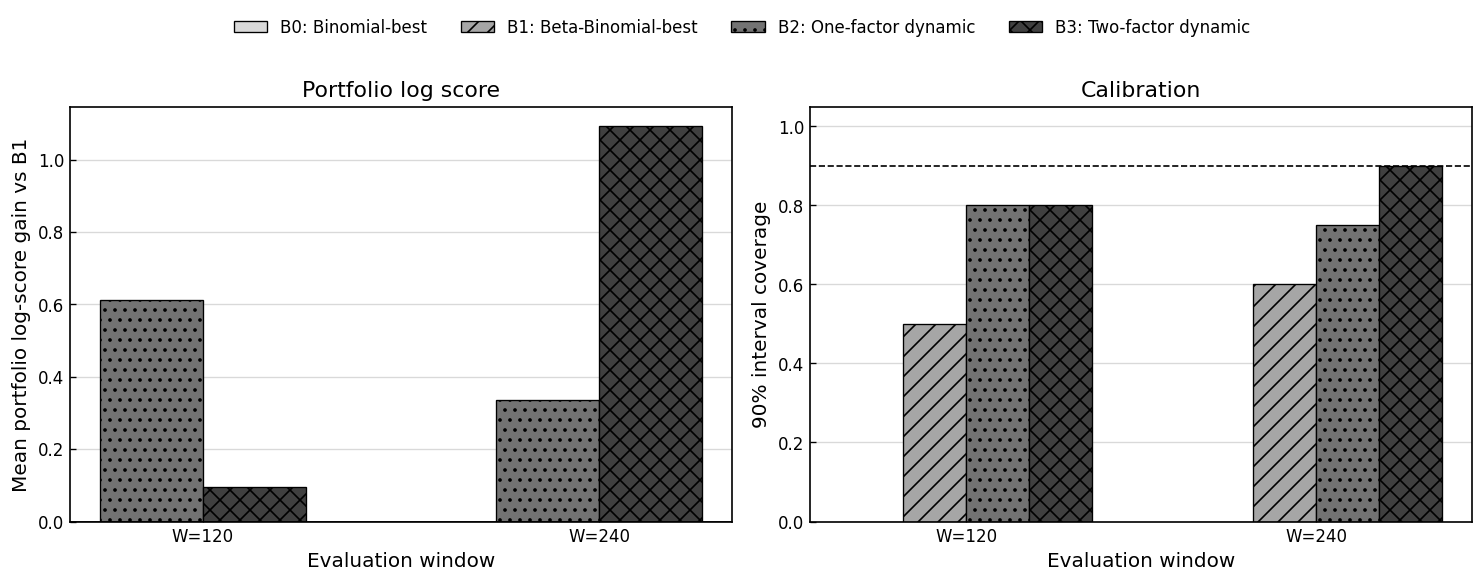

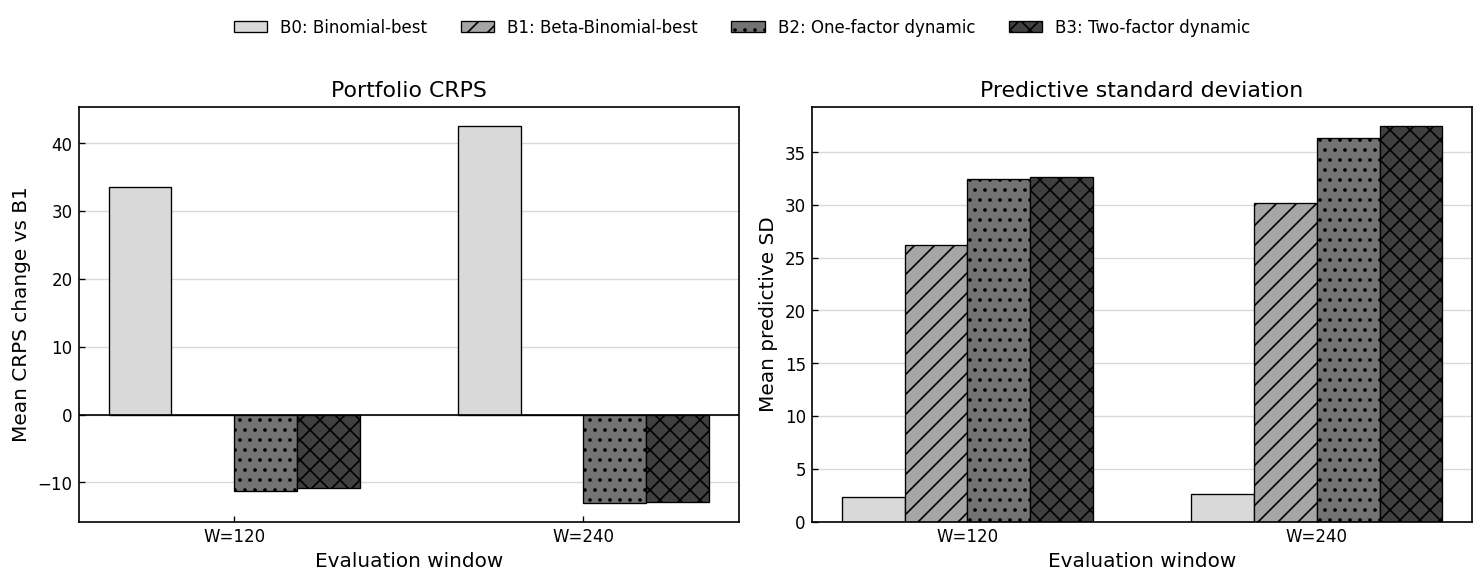

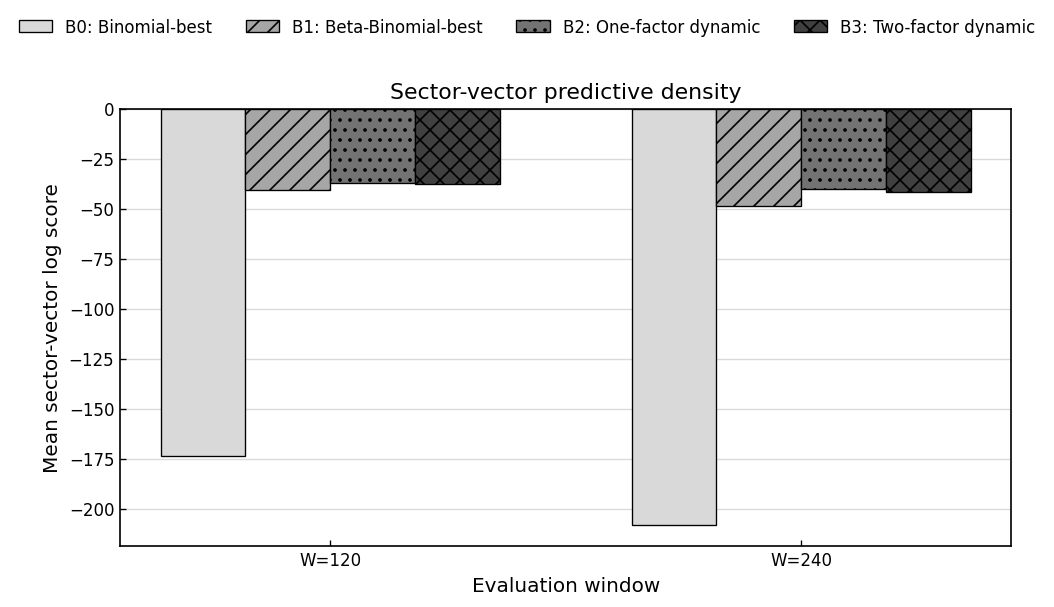

In [11]:
# ============================================================
# 9. Paper forecast figures
# ============================================================

def forecast_model_label(m):
    return MODEL_LABELS.get(m, m)

W_vals = sorted(comp["evaluation_start_months"].dropna().unique())
x = np.arange(len(W_vals))
style_map = {
    "B0_binomial_best":     {"color": "0.85", "hatch": ""},
    "B1_betabinomial_best": {"color": "0.65", "hatch": "//"},
    B2_MODEL:               {"color": "0.45", "hatch": ".."},
    B3_MODEL:               {"color": "0.25", "hatch": "xx"},
}

# ------------------------------------------------------------
# Figure 8: portfolio log-score gain vs B1 and 90% coverage.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

log_models = [B2_MODEL, B3_MODEL]
width = 0.26
for j, m in enumerate(log_models):
    g = comp.query("paper_model == @m").set_index("evaluation_start_months").reindex(W_vals)
    st = style_map[m]
    axes[0].bar(
        x + (j - 0.5) * width,
        g["delta_log_score_portfolio_vs_B1"],
        width=width,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor="black",
        linewidth=0.8,
        label=forecast_model_label(m),
    )
axes[0].axhline(0, color="black", lw=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"W={int(w)}" for w in W_vals])
axes[0].set_xlabel("Evaluation window")
axes[0].set_ylabel("Mean portfolio log-score gain vs B1")
axes[0].set_title("Portfolio log score")
axes[0].grid(axis="y", color="0.85", linewidth=0.8)
axes[0].set_axisbelow(True)

cov_models = ["B0_binomial_best", "B1_betabinomial_best", B2_MODEL, B3_MODEL]
width = 0.18
for j, m in enumerate(cov_models):
    g = comp.query("paper_model == @m").set_index("evaluation_start_months").reindex(W_vals)
    st = style_map[m]
    axes[1].bar(
        x + (j - 1.5) * width,
        g["coverage_pi90_portfolio"],
        width=width,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor="black",
        linewidth=0.8,
        label=forecast_model_label(m),
    )
axes[1].axhline(0.90, color="black", lw=1.0, linestyle="--")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"W={int(w)}" for w in W_vals])
axes[1].set_xlabel("Evaluation window")
axes[1].set_ylabel("90% interval coverage")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Calibration")
axes[1].grid(axis="y", color="0.85", linewidth=0.8)
axes[1].set_axisbelow(True)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.92])
savefig_paper(fig, "fig08_portfolio_logscore_coverage_common_eps")
plt.show()

# ------------------------------------------------------------
# Figure S02: portfolio CRPS and predictive standard deviation.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
width = 0.18
for j, m in enumerate(cov_models):
    g = comp.query("paper_model == @m").set_index("evaluation_start_months").reindex(W_vals)
    st = style_map[m]
    axes[0].bar(
        x + (j - 1.5) * width,
        g["delta_crps_portfolio_vs_B1"],
        width=width,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor="black",
        linewidth=0.8,
        label=forecast_model_label(m),
    )
    axes[1].bar(
        x + (j - 1.5) * width,
        g["pred_sd_portfolio_defaults"],
        width=width,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor="black",
        linewidth=0.8,
    )
axes[0].axhline(0, color="black", lw=1.0)
axes[0].set_title("Portfolio CRPS")
axes[0].set_ylabel("Mean CRPS change vs B1")
axes[1].set_title("Predictive standard deviation")
axes[1].set_ylabel("Mean predictive SD")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([f"W={int(w)}" for w in W_vals])
    ax.set_xlabel("Evaluation window")
    ax.grid(axis="y", color="0.85", linewidth=0.8)
    ax.set_axisbelow(True)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.92])
savefig_paper(fig, "figS02_portfolio_crps_predsd_common_eps")
plt.show()

# ------------------------------------------------------------
# Figure 9: sector-vector predictive density.
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 5.0))
width = 0.18
for j, m in enumerate(cov_models):
    g = comp.query("paper_model == @m").set_index("evaluation_start_months").reindex(W_vals)
    st = style_map[m]
    ax.bar(
        x + (j - 1.5) * width,
        g["mean_log_score_sector_vector"],
        width=width,
        color=st["color"],
        hatch=st["hatch"],
        edgecolor="black",
        linewidth=0.8,
        label=forecast_model_label(m),
    )
ax.set_xticks(x)
ax.set_xticklabels([f"W={int(w)}" for w in W_vals])
ax.set_xlabel("Evaluation window")
ax.set_ylabel("Mean sector-vector log score")
ax.set_title("Sector-vector predictive density")
ax.grid(axis="y", color="0.85", linewidth=0.8)
ax.set_axisbelow(True)
fig.legend(*ax.get_legend_handles_labels(), loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.92])
savefig_paper(fig, "fig09_sector_vector_predictive_density_common_eps")
plt.show()
